# 🩸 Detección y conteo de glóbulos y plaquetas

Este notebook usa un modelo YOLO ya entrenado para detectar y contar:
- **GR** — glóbulos rojos
- **GB** — glóbulos blancos
- **PQT** — plaquetas

### Cómo usarlo:
1. Corré las celdas en orden, de arriba a abajo (▶️ en cada una, o `Entorno de ejecución → Ejecutar todas`)
2. En la **Celda 2** subís el archivo `runs.zip` (donde está guardado el modelo ya entrenado)
3. En la **Celda 4** subís la foto de la muestra que querés analizar
4. Listo — vas a ver la imagen con las detecciones marcadas y el conteo final

No hace falta entrenar nada, el modelo ya viene entrenado dentro del `runs.zip`.

## Celda 1 — Instalar lo necesario

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO
import zipfile
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Celda 2 — Subir el modelo entrenado (runs.zip)

In [ ]:
from google.colab import files

print('Subí el archivo runs.zip')
uploaded_model = files.upload()

Subí el archivo runs.zip


Saving runs.zip to runs.zip


## Celda 3 — Descomprimir y cargar el modelo

In [ ]:
nombre_zip = list(uploaded_model.keys())[0]

with zipfile.ZipFile(nombre_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/modelo_extraido')

# Buscamos el best.pt automáticamente en toda la carpeta extraída,
# sin importar la estructura interna del zip (con o sin carpeta 'content/' de más)
ruta_modelo = None
for root, dirs, files_ in os.walk('/content/modelo_extraido'):
    if 'best.pt' in files_:
        ruta_modelo = os.path.join(root, 'best.pt')
        break

if ruta_modelo is None:
    print('No se encontró best.pt dentro del zip. Revisá que sea el runs.zip correcto.')
else:
    print(f'Modelo encontrado en: {ruta_modelo}')
    best_model = YOLO(ruta_modelo)
    print('Modelo cargado correctamente ✅')

Modelo encontrado en: /content/modelo_extraido/content/runs/detect/hematologia/globulos_y_plaquetas_combinado/weights/best.pt
Modelo cargado correctamente ✅


## Celda 4 — Subir la imagen de la muestra a analizar

In [ ]:
print('Subí la foto de la muestra que querés analizar')
uploaded_imagen = files.upload()
imagen = list(uploaded_imagen.keys())[0]

Subí la foto de la muestra que querés analizar


Saving pruebaplaqueta (1).png to pruebaplaqueta (1).png


## Celda 5 — Detección, conteo y visualización del resultado


image 1/1 /content/pruebaplaqueta (1).png: 640x640 51 GRs, 3 PQTs, 16.0ms
Speed: 4.1ms preprocess, 16.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

===== CONTEO =====
GR: 51
PQT: 3


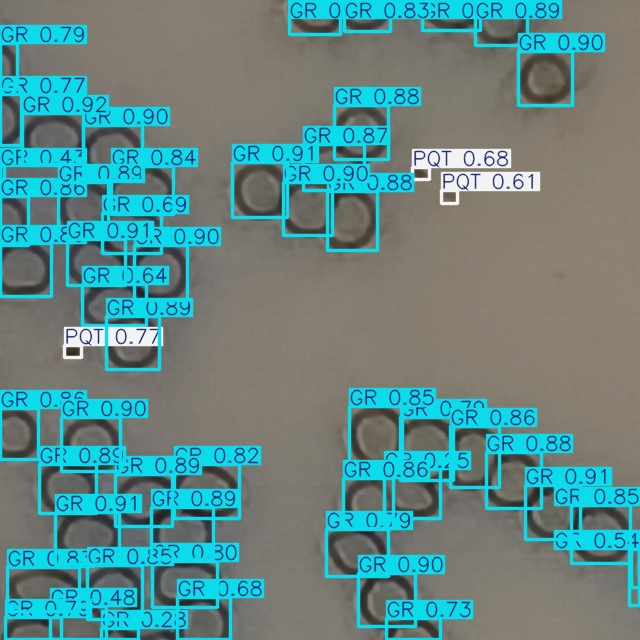

In [ ]:
from IPython.display import Image as IPImage, display

results = best_model.predict(
    source=imagen,
    conf=0.25,
    save=True
)

r = results[0]
nombres = r.names

conteo = {}
for clase in r.boxes.cls.cpu().numpy():
    nombre = nombres[int(clase)]
    conteo[nombre] = conteo.get(nombre, 0) + 1

print('\n===== CONTEO =====')
for clase, cantidad in conteo.items():
    print(f'{clase}: {cantidad}')

# Mostramos la imagen con las detecciones dibujadas
archivos_resultado = os.listdir(r.save_dir)
ruta_resultado = os.path.join(r.save_dir, archivos_resultado[0])
display(IPImage(filename=ruta_resultado))

### ¿Querés analizar otra imagen?
Volvé a correr la **Celda 4** (subir nueva foto) y después la **Celda 5** de nuevo. No hace falta repetir las celdas 1 a 3.